In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# ── CREATE CUSTOMER DATASET ──
np.random.seed(42)
n = 2000

countries = ['United Kingdom','Germany','France','Netherlands','Spain']
products  = ['Premium Widget','Standard Widget','Basic Widget',
             'Deluxe Package','Starter Pack','Enterprise Suite',
             'Gold Membership','Silver Membership','Bronze Pack']

dates = pd.date_range('2019-01-01', '2021-12-31', periods=n)

df = pd.DataFrame({
    'CustomerID':  np.random.randint(1000, 1500, n),
    'InvoiceDate': np.sort(dates),
    'Revenue':     np.round(np.random.exponential(150, n) + 20, 2),
    'Country':     np.random.choice(countries, n, p=[0.5,0.15,0.15,0.1,0.1]),
    'Product':     np.random.choice(products, n),
})

print("✅ Dataset ready!")
print(f"Transactions: {len(df):,}")
print(f"Unique Customers: {df['CustomerID'].nunique():,}")
print(f"Date Range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"Total Revenue: £{df['Revenue'].sum():,.2f}")
df.head()

✅ Dataset ready!
Transactions: 2,000
Unique Customers: 489
Date Range: 2019-01-01 to 2021-12-31
Total Revenue: £343,176.51


,CustomerID,InvoiceDate,Revenue,Country,Product
0,1102,2019-01-01 00:00:00.000000,156.05,United Kingdom,Basic Widget
1,1435,2019-01-01 13:08:47.663831,59.21,France,Premium Widget
2,1348,2019-01-02 02:17:35.327663,39.27,United Kingdom,Gold Membership
3,1270,2019-01-02 15:26:22.991495,32.01,United Kingdom,Deluxe Package
4,1106,2019-01-03 04:35:10.655327,198.75,United Kingdom,Standard Widget


In [2]:
# ── RFM ANALYSIS ──
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceDate', 'count'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

# Score 1-5
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Segment
def segment(row):
    if row['RFM_Total'] >= 13: return 'Champions'
    elif row['RFM_Total'] >= 10: return 'Loyal Customers'
    elif row['RFM_Total'] >= 7: return 'Potential Loyalists'
    elif row['R_Score'] >= 4: return 'Recent Customers'
    elif row['F_Score'] >= 4: return 'At Risk'
    else: return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment, axis=1)

print("✅ RFM Analysis Complete!")
print(f"\nCustomer Segments:")
print(rfm['Segment'].value_counts())
print(f"\nTop 5 Champions:")
print(rfm[rfm['Segment']=='Champions'][['CustomerID','Recency','Frequency','Monetary']].head())

✅ RFM Analysis Complete!

Customer Segments:
Segment
Loyal Customers        144
Lost Customers         129
Potential Loyalists    119
Champions               89
Recent Customers         8
Name: count, dtype: int64

Top 5 Champions:
    CustomerID  Recency  Frequency  Monetary
13        1013        1          7    729.97
16        1016       37          5   1373.56
23        1024       25          7   1254.32
37        1038       47          9   2295.31
40        1041       48          7    860.74


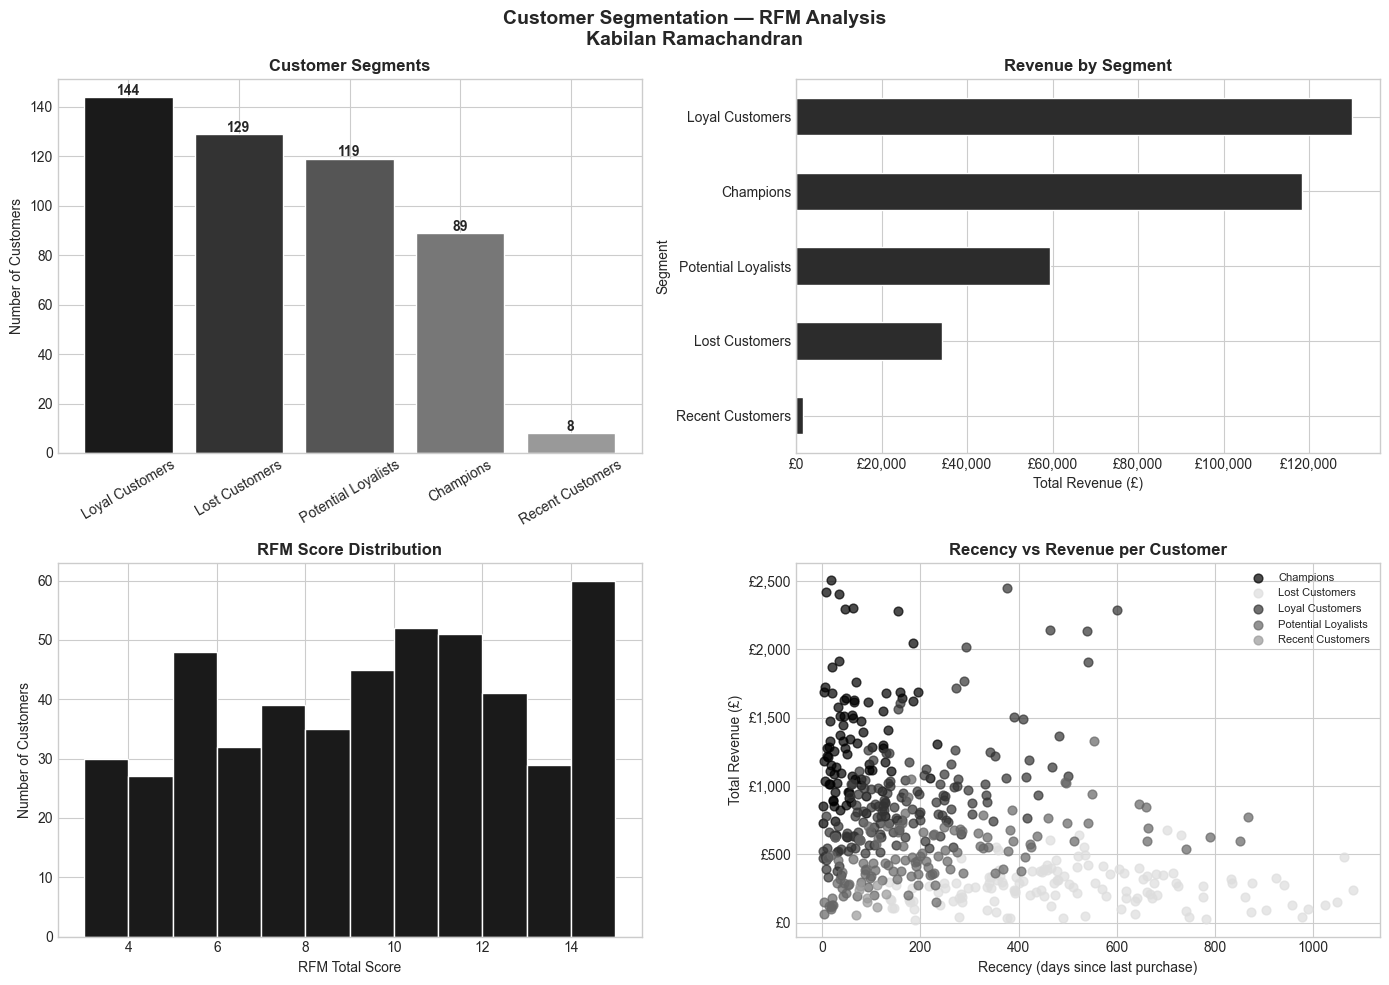

✅ Charts saved!


In [3]:
# ── VISUALISATIONS ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Segmentation — RFM Analysis\nKabilan Ramachandran',
             fontsize=14, fontweight='bold')

# Chart 1: Segment Distribution
ax1 = axes[0,0]
seg_counts = rfm['Segment'].value_counts()
colors = ['#1A1A1A','#333333','#555555','#777777','#999999']
ax1.bar(seg_counts.index, seg_counts.values, color=colors, edgecolor='white')
ax1.set_title('Customer Segments', fontweight='bold')
ax1.set_ylabel('Number of Customers')
ax1.tick_params(axis='x', rotation=30)
for i, v in enumerate(seg_counts.values):
    ax1.text(i, v+1, str(v), ha='center', fontweight='bold')

# Chart 2: Revenue by Segment
ax2 = axes[0,1]
seg_rev = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=True)
seg_rev.plot(kind='barh', ax=ax2, color='#2C2C2C', edgecolor='white')
ax2.set_title('Revenue by Segment', fontweight='bold')
ax2.set_xlabel('Total Revenue (£)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))

# Chart 3: RFM Score Distribution
ax3 = axes[1,0]
ax3.hist(rfm['RFM_Total'], bins=12, color='#1A1A1A', edgecolor='white')
ax3.set_title('RFM Score Distribution', fontweight='bold')
ax3.set_xlabel('RFM Total Score')
ax3.set_ylabel('Number of Customers')

# Chart 4: Recency vs Monetary
ax4 = axes[1,1]
seg_colors = {'Champions':'#000000','Loyal Customers':'#333333',
              'Potential Loyalists':'#666666','Recent Customers':'#999999',
              'At Risk':'#BBBBBB','Lost Customers':'#DDDDDD'}
for seg, group in rfm.groupby('Segment'):
    ax4.scatter(group['Recency'], group['Monetary'],
                label=seg, color=seg_colors.get(seg,'#888888'),
                alpha=0.7, s=40)
ax4.set_title('Recency vs Revenue per Customer', fontweight='bold')
ax4.set_xlabel('Recency (days since last purchase)')
ax4.set_ylabel('Total Revenue (£)')
ax4.legend(fontsize=8)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))

plt.tight_layout()
plt.savefig('customer_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved!")

In [4]:
# ── BUSINESS INSIGHTS ──
print("=" * 55)
print("   CUSTOMER SEGMENTATION INSIGHTS")
print("=" * 55)

total_customers = len(rfm)
total_revenue = rfm['Monetary'].sum()

for seg in rfm['Segment'].value_counts().index:
    seg_df = rfm[rfm['Segment']==seg]
    count = len(seg_df)
    rev = seg_df['Monetary'].sum()
    pct_cust = count/total_customers*100
    pct_rev = rev/total_revenue*100
    print(f"\n{seg}:")
    print(f"  Customers: {count} ({pct_cust:.1f}%)")
    print(f"  Revenue:   £{rev:,.2f} ({pct_rev:.1f}%)")
    print(f"  Avg spend: £{seg_df['Monetary'].mean():,.2f}")

print("\n" + "="*55)
print("✅ RFM Analysis — Kabilan Ramachandran")
print("="*55)

   CUSTOMER SEGMENTATION INSIGHTS

Loyal Customers:
  Customers: 144 (29.4%)
  Revenue:   £130,037.24 (37.9%)
  Avg spend: £903.04

Lost Customers:
  Customers: 129 (26.4%)
  Revenue:   £34,092.80 (9.9%)
  Avg spend: £264.29

Potential Loyalists:
  Customers: 119 (24.3%)
  Revenue:   £59,363.14 (17.3%)
  Avg spend: £498.85

Champions:
  Customers: 89 (18.2%)
  Revenue:   £118,184.21 (34.4%)
  Avg spend: £1,327.91

Recent Customers:
  Customers: 8 (1.6%)
  Revenue:   £1,499.12 (0.4%)
  Avg spend: £187.39

✅ RFM Analysis — Kabilan Ramachandran
